# Conduct a Statistical Analysis Using Python
## by <i>Andreas Grotz</i>

## Table of Contents
- [Introduction](#intro)
- [Imports](#import)
- [Data Cleaning](#cleaning)
- [Descriptive Statistics](#descr)
- [Visualization](#visual)
- [Hypothesis Tests](#tests)
- [Summary](#summary)

<a id='intro'></a>
### Introduction

In this project, we conduct a complete statistical analysis for a dataset on passengers of the Titanic (https://www.kaggle.com/c/titanic/data). This dataset contains biometric and economic information on the Titanic's passengers, as well as whether each passenger survived its sinking. More precisely, the Kaggle dataset is already split into a training batch (train.csv) and a test batch (test.csv), and we will focus on the training set in this project.

We will analyze some statistical relationships between age, sex, fare price, and survival probability in the data

After importing modules and loading the data, we perform some cleaning tasks, explore descriptive statistics and create some visualizations, before delving into hypothesis testing. We conclude by a short summary of our findings.


<a id='import'></a>
### Imports

In this section, we import required Python modules, and we load our dataset to a Pandas dataframe.

In [1]:
#!pip install numpy
#!pip install pandas
#!pip install matplotlib
#!pip install seaborn
#!pip install scipy

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv("titanic_train.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The dataset contains the following columns, with descriptions provided on the Kaggle website:
- Survived (nominal):	Survival (0 = No, 1 = Yes)
- Pclass (ordinal): Ticket class (1 = 1st, 2 = 2nd, 3 = 3rd)
- Name (nominal): Passenger's name
- Sex (nominal): Sex 	
- Age (numerical): Age in years 	
- SibSp (numerical): # of siblings / spouses aboard the Titanic 	
- Parch (numerical): # of parents / children aboard the Titanic 	
- Ticket (nominal): Ticket number 	
- Fare (numerical): Passenger fare 	
- Cabin (nominal): Cabin number 	
- Embarked (nominal):	Port of Embarkation (C = Cherbourg, Q = Queenstown, S = Southampton)

<a id='cleaning'></a>
### Data Cleaning

In this section, we perform data cleaning and first look at the data quality:

In [4]:
sum(df.duplicated())

0

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

The cabin number is missing for a significant number of rows. There is no meaningful way to impute that information. Also, we will not use that column going forward, and therefore drop it.

In [7]:
df.drop(labels='Cabin', axis=1, inplace=True)

This leaves us with 177 entries with missing values for Age and 2 entries with missing values for Embarked. We drop these entries to get a clean dataset.

In [8]:
df.dropna(axis=0, inplace=True)

We drop some more columns that we will not use going forward.

In [9]:
df.drop(labels=['PassengerId','Name','Ticket'], axis=1, inplace=True)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  712 non-null    int64  
 1   Pclass    712 non-null    int64  
 2   Sex       712 non-null    object 
 3   Age       712 non-null    float64
 4   SibSp     712 non-null    int64  
 5   Parch     712 non-null    int64  
 6   Fare      712 non-null    float64
 7   Embarked  712 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 50.1+ KB


<a id='descr'></a>
### Descriptive Statistics

Our goal is to ...

In [11]:
df[['Age','SibSp','Parch','Fare']].describe()

,Age,SibSp,Parch,Fare
count,712.000000,712.000000,712.000000,712.000000
mean,29.642093,0.514045,0.432584,34.567251
std,14.492933,0.930692,0.854181,52.938648
min,0.420000,0.000000,0.000000,0.000000
25%,20.000000,0.000000,0.000000,8.050000
50%,28.000000,0.000000,0.000000,15.645850
75%,38.000000,1.000000,1.000000,33.000000
max,80.000000,5.000000,6.000000,512.329200


In [12]:
df.Pclass.value_counts()


Pclass
3    355
1    184
2    173
Name: count, dtype: int64

In [13]:
df.Survived.value_counts()

Survived
0    424
1    288
Name: count, dtype: int64

In [14]:
df.Sex.value_counts()

Sex
male      453
female    259
Name: count, dtype: int64

In [15]:
df.Embarked.value_counts()

Embarked
S    554
C    130
Q     28
Name: count, dtype: int64

In [16]:
df[['Age','Fare']].corr()

,Age,Fare
Age,1.000000,0.093143
Fare,0.093143,1.000000


In [17]:
df.groupby('Sex').Fare.describe()

,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
female,259.0,47.332433,61.517487,6.75,13.0000,26.0,56.9646,512.3292
male,453.0,27.268836,45.841889,0.00,7.8958,13.0,28.5000,512.3292


In [18]:
df.groupby('Embarked').Fare.describe()

,count,mean,std,min,25%,50%,75%,max
Embarked,,,,,,,,
C,130.0,68.296767,90.557822,4.0125,14.4542,36.2521,81.42810,512.3292
Q,28.0,18.265775,21.843582,6.7500,7.7500,7.7500,18.90625,90.0000
S,554.0,27.476284,36.546362,0.0000,8.0500,13.0000,27.86250,263.0000


In [19]:
df.groupby('Survived').Fare.describe()

,count,mean,std,min,25%,50%,75%,max
Survived,,,,,,,,
0,424.0,22.965456,31.448825,0.0,7.8958,11.8875,26.55,263.0000
1,288.0,51.647672,70.664499,0.0,13.0000,26.2500,65.00,512.3292


These statistics ...

<a id='visual'></a>
### Visualization

In the following, we focus on the nominal variable Survived, the ordinal variable Sex, and the numerical variables Age and Fare. We first look at univariate distributions of the variables under consideration.

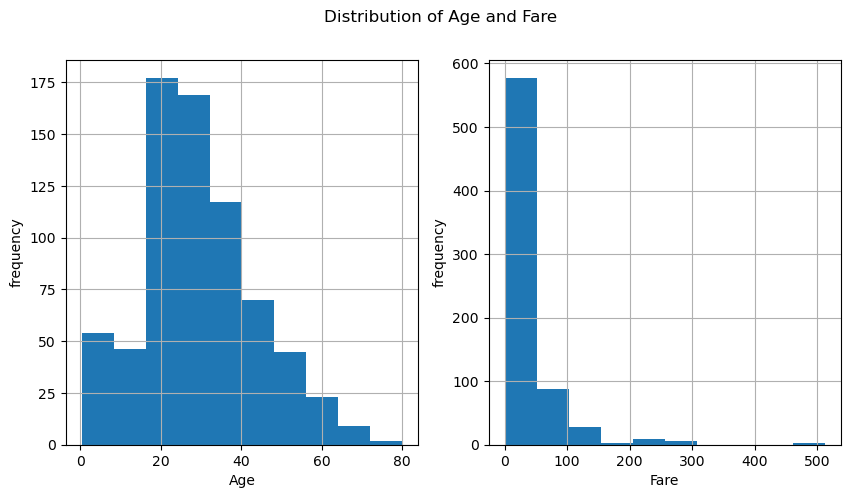

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5));
df.Age.hist(ax=axes[0]);
df.Fare.hist(ax=axes[1]);
axes[0].set(xlabel='Age', ylabel='frequency')
axes[1].set(xlabel='Fare', ylabel='frequency')
plt.suptitle('Distribution of Age and Fare')
plt.show()

Histograms show that Age is right-skewd with mode aroud 20 and range from 0 to 80. Fare is also right-skewed with the bulk of fares below 50 and outliers out to 500.

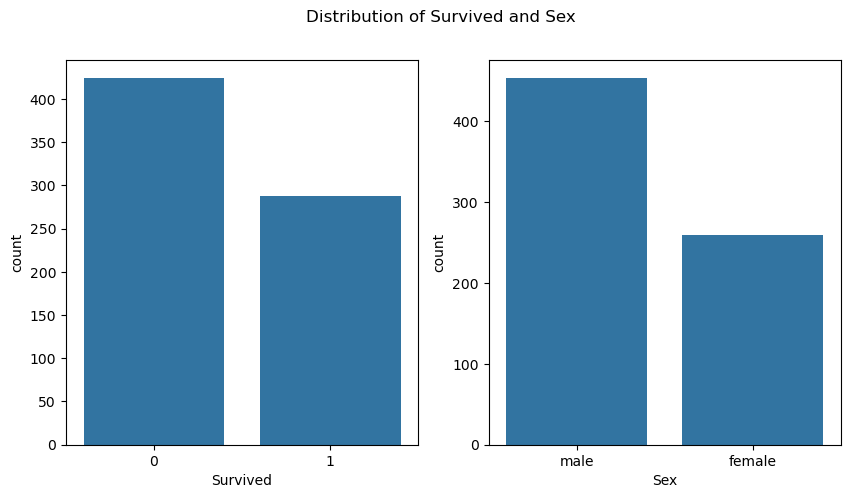

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5));
sns.countplot(data=df, x='Survived', ax=axes[0]);
sns.countplot(data=df, x='Sex', ax=axes[1]);
axes[0].set(xlabel='Survived', ylabel='count')
axes[1].set(xlabel='Sex', ylabel='count')
plt.suptitle('Distribution of Survived and Sex')
plt.show()

Around 300 passengers in the cleaned data survived, while slightly around 400 passangers did not survive. Also, there are roughly twice as many males as females in the data.

We now start looking at bivariate plots in order to understand relationships between the data:

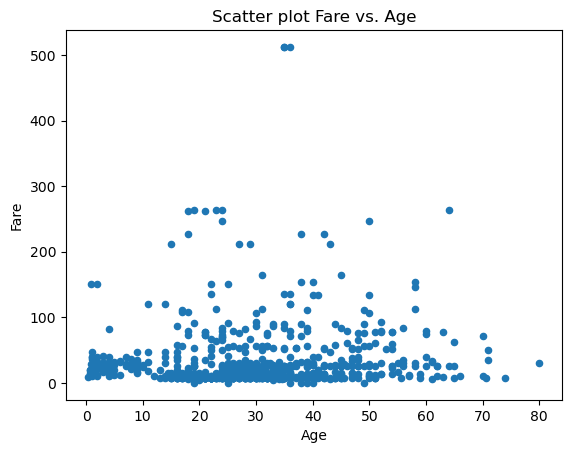

In [22]:
ax = df.plot.scatter(x='Age', y='Fare');
plt.title('Scatter plot Fare vs. Age');
plt.show()

A scatter plot for the numerical variables Age and Fare suggests that there is no (linear) relationship between the data. This motivates our first hypothesis that Age and Fare are uncorrelated.

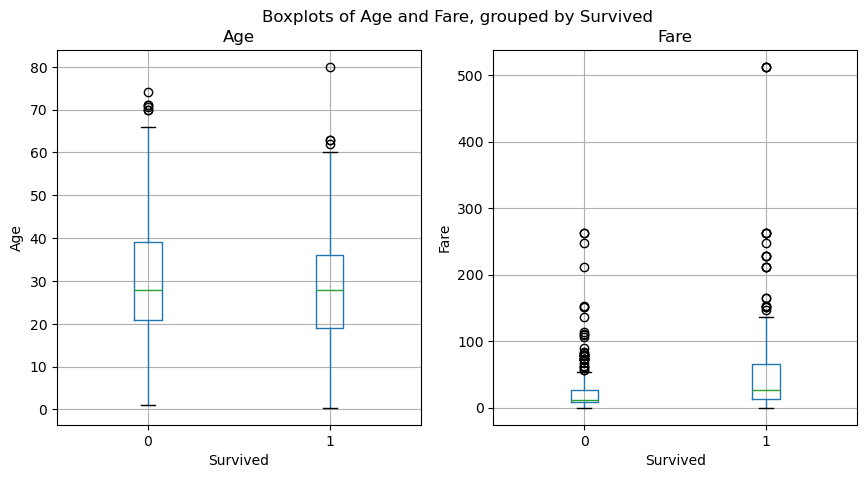

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5));
df.boxplot(column='Age', by='Survived', ax=axes[0]);
df.boxplot(column='Fare', by='Survived', ax=axes[1]);
axes[0].set(xlabel='Survived', ylabel='Age')
axes[1].set(xlabel='Survived', ylabel='Fare')
plt.suptitle('Boxplots of Age and Fare, grouped by Survived')
plt.show()

The boxplots for Age grouped by Survived suggests the distribution of ages is the same among survivors and non-survivors, both with median around 30 and 25%/75% quantiles around 20/40. On the other hand, the boxplots for Fare grouped by Survived indicates a difference in distribution, with the median Fare of survivors being more than double than the median Fare of non-survivors.

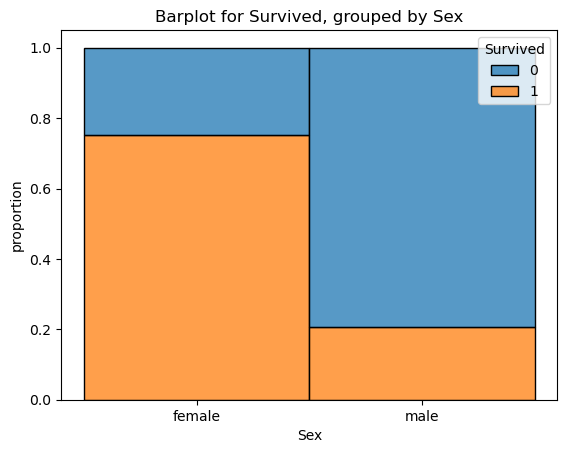

In [24]:
grouped_data_sex = df.groupby(['Sex', 'Survived']).size().reset_index(name='counts');
grouped_data_sex['total'] = grouped_data_sex.groupby('Sex')['counts'].transform('sum')
grouped_data_sex['proportion'] = grouped_data_sex['counts'] / grouped_data_sex['total']
ax = sns.histplot(grouped_data_sex, x='Sex', hue='Survived', weights='proportion', multiple='stack');
plt.xlabel('Sex')
plt.ylabel('proportion')
plt.title('Barplot for Survived, grouped by Sex')
plt.suptitle('')
plt.show()

The stacked bar plot for Sex, grouped by Survived, indicates that the survival probability for females is a lot higher than for males (around 75% for females vs. around 20% for males).

<a id='tests'></a>
### Hypothesis Tests

We will now test whether the observations we made in the visualization section are statistically significant.

We start with a correlation test for Age and Fare:
- Null hypothesis: Age and Fare are uncorrelated
- Alternative hypothesis: The correlation from Age and Fare is different from zero

In [25]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.pearsonr.html
stats.pearsonr(df.Fare, df.Age, alternative='two-sided')

PearsonRResult(statistic=np.float64(0.09314251789411518), pvalue=np.float64(0.01290455340704157))

The test statistics gives an expected correlation of 9%. The p-Value however is 0.0129, hence we cannot reject the null hypothesis at the 99% level, implying that Age and Fare are indeed uncorrelated at that level of significance.

We next perform a two-sample t-test for Age:
- Null hypothesis: The mean Age is the same for survivors and non-survivors
- Alternative hypothesis: The mean Age is different for survivors and non-survivors

In [26]:
obs_age_survTrue = df[df.Survived == 1].Age
obs_age_survFalse = df[df.Survived == 0].Age
print(f'Mean age for survivors: {obs_age_survTrue.mean()}')
print(f'Mean age for non-survivors: {obs_age_survFalse.mean()}')
stats.ttest_ind(obs_age_survTrue, obs_age_survFalse, alternative='two-sided')

Mean age for survivors: 28.19329861111111
Mean age for non-survivors: 30.62617924528302


TtestResult(statistic=np.float64(-2.2043427748445956), pvalue=np.float64(0.027820316250851285), df=np.float64(710.0))

The p-Value is 0.0278, hence we cannot reject the null hypothesis at the 99% level, implying that survivors and non-survivors indeed have the same mean age at that level of significance.

We do the same test for Fare:
- Null hypothesis: The mean Fare is the same for survivors and non-survivors
- Alternative hypothesis: The mean Fare is different for survivors and non-survivors

In [27]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html
obs_fare_survTrue = df[df.Survived == 1].Fare
obs_fare_survFalse = df[df.Survived == 0].Fare
print(f'Mean fare for survivors: {obs_fare_survTrue.mean()}')
print(f'Mean fare for non-survivors: {obs_fare_survFalse.mean()}')
stats.ttest_ind(obs_fare_survTrue, obs_fare_survFalse, alternative='two-sided')

Mean fare for survivors: 51.647671875
Mean fare for non-survivors: 22.96545636792453


TtestResult(statistic=np.float64(7.355647335343511), pvalue=np.float64(5.256795780683418e-13), df=np.float64(710.0))

The p-Value is 5e-13, hence we easily reject the null hypothesis at the 99% level and accept the alternative hypothesis, implying that survivors and non-survivors indeed have paid different fares on average at that level of significance.

We finally use Fisher's Exact test to check whether the survival probability differs for males and females:
- Null hypothesis: The odds ratio for males and females is equal to one, i.e. they have the same survival probability
- Alternative hypothesis: The odds ratio for males and females is equal to one, i.e. they have different survival probabilities

In [28]:
# https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.fisher_exact.html
obs = grouped_data_sex.pivot(index='Sex', columns='Survived', values='counts')
obs = obs[[1,0]]
obs

Survived,1,0
Sex,,
female,195,64
male,93,360


In [29]:
stats.fisher_exact(obs.to_numpy())

SignificanceResult(statistic=np.float64(11.794354838709678), pvalue=np.float64(1.8885888329631993e-47))

With a p-Value of 1e-47, we can comfortably reject the null hypothesis at the 99% level, implying that that males and females have different survival probabilities. In fact, the maximum likelyhood estimation for the odds ratio of 11.79 implies that it is around ten times more likely for a female to survive than for a male.

<a id='summary'></a>
### Summary

We have ...

In [30]:
# Let us finally generate the requirements file for reproducibility.
!pip freeze > requirements.txt